## Models to evaluate
- Logistic Regression
- Naive Bayes
- Random Forest
- LightGBM or XGBoost

In [2]:
import numpy as np
import pandas as pd
#Load dataset
dataset = pd.read_csv("healthFactors_dataset.csv")

## Train models with sample weights

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import lightgbm as lgb

#prepare data

#Drop CVD and Is Minority columns for X
X = dataset.drop(['Cardiovascular Disease'], axis=1)
#Extract output variable into Y
Y = dataset['Cardiovascular Disease']

"""
 stratify=Y: performs a stratified split based on the target, preserving the class
 proportions in both train and test—important for imbalanced datasets.
"""

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

## Train models

In [17]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=500),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'XGBoost': xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    'LightGBM':lgb.LGBMClassifier(
       objective='binary',     # ← Increased
       learning_rate=0.01,      # ← Slower
       max_depth=5,
       num_leaves=50,
       subsample=0.8,
       colsample_bytree=0.8,
       random_state=50
    )
}

Training LogisticRegression...
Training Random Forest...
Training XGBoost...
Training LightGBM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 13486, number of negative: 13818
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000487 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 412
[LightGBM] [Info] Number of data points in the train set: 27304, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.493920 -> initscore=-0.024320
[LightGBM] [Info] Start training from score -0.024320
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wi

c:\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:46:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


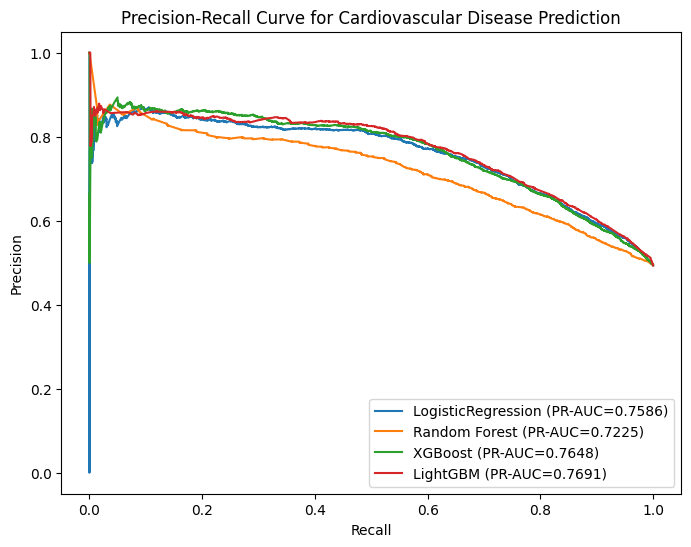

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc
import numpy as np
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb



results = {}

plt.figure(figsize=(8, 6))
for name, model in models.items():
    print(f"Training {name}...")
    if name == "LightGBM":
        model.fit(
            X_train,
            Y_train.to_numpy(),
         
        )
        y_scores = model.predict_proba(X_test)[:, 1]
    elif name == "Neural Network":
        # Already trained above, just predict
        y_scores = model.predict(X_test).flatten()
    else:
        X_train_np = np.ascontiguousarray(X_train, dtype=np.float32)
        Y_train_np = np.ascontiguousarray(Y_train, dtype=np.int32)
        X_test_np = np.ascontiguousarray(X_test, dtype=np.float32)
        Y_test_np = np.ascontiguousarray(Y_test, dtype=np.int32)
        model.fit(X_train_np, Y_train_np)
        y_scores = model.predict_proba(X_test_np)[:, 1]

    precision, recall, _ = precision_recall_curve(Y_test, y_scores)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f"{name} (PR-AUC={pr_auc:.4f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Cardiovascular Disease Prediction")
plt.legend()
plt.show()

# Print model performance
for model_name, score in results.items():
    print(f"{model_name}: Precision-Recall AUC = {score:.4f}")


Training LogisticRegression...
Training Random Forest...
Training XGBoost...
Training LightGBM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 13486, number of negative: 13818
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000498 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 412
[LightGBM] [Info] Number of data points in the train set: 27304, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.493920 -> initscore=-0.024320
[LightGBM] [Info] Start training from score -0.024320
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wi

c:\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:46:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


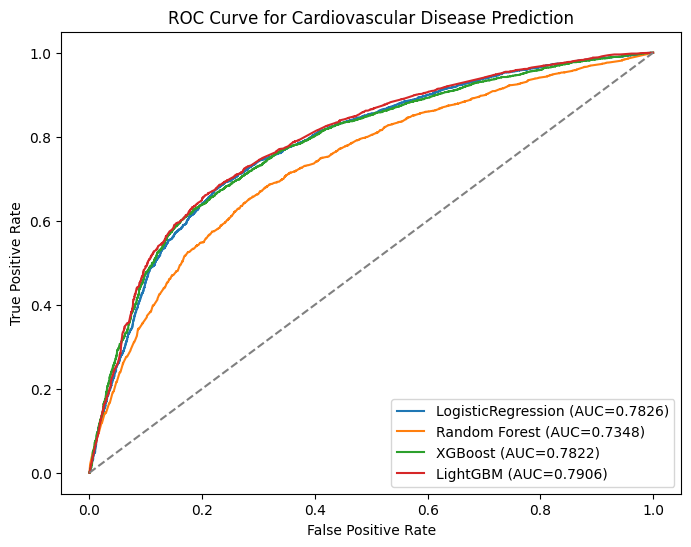

In [19]:

# ...existing code...
from sklearn.metrics import roc_auc_score, roc_curve


plt.figure(figsize=(8, 6))
for name, model in models.items():
    print(f"Training {name}...")
    if name == "LightGBM":
        model.fit(
            X_train,
            Y_train.to_numpy(),
         
        )
        y_scores = model.predict_proba(X_test)[:, 1]
    elif name == "Neural Network":
        # Already trained above, just predict
        y_scores = model.predict(X_test).flatten()
    else:
        X_train_np = np.ascontiguousarray(X_train, dtype=np.float32)
        Y_train_np = np.ascontiguousarray(Y_train, dtype=np.int32)
        X_test_np = np.ascontiguousarray(X_test, dtype=np.float32)
        Y_test_np = np.ascontiguousarray(Y_test, dtype=np.int32)
        model.fit(X_train_np, Y_train_np)
        y_scores = model.predict_proba(X_test_np)[:, 1]

    fpr, tpr, _ = roc_curve(Y_test, y_scores)
    auc_score = roc_auc_score(Y_test, y_scores)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_score:.4f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Cardiovascular Disease Prediction")
plt.legend()
plt.show()
# ...existing code...

## Save models


In [20]:
import os
import joblib

os.makedirs("saved_models_tausif", exist_ok=True)

# scikit-learn models -> joblib
#joblib.dump(models['LogisticRegression'], "saved_models/logistic_regression.joblib")
#joblib.dump(models['Random Forest'], "saved_models/random_forest.joblib")

# XGBoost -> native format
#models['XGBoost'].save_model("saved_models/xgboost_model.json")

# LightGBM -> save underlying Booster (created after fit)
if hasattr(models['LightGBM'], "booster_"):
    models['LightGBM'].booster_.save_model("health_model.txt")
else:
    joblib.dump(models['LightGBM'], "saved_models_tausif/lightgbm_model.joblib")

print("Models saved to ./saved_models")

Models saved to ./saved_models


In [ ]:
Y_train.shape

(23066,)

In [ ]:
# Find optimal threshold based on clinical preference
from sklearn.metrics import precision_recall_curve

# Get 1D positive-class scores
y_scores = models['LightGBM'].predict_proba(X_train)
if y_scores.ndim == 2:
    y_scores = y_scores[:, 1]

precision, recall, thresholds = precision_recall_curve(
    Y_train,
    y_scores,
    # sample_weight=weights_train,  # optional
)

# thresholds has length len(precision) - 1
prec_t = precision[:-1]
rec_t  = recall[:-1]

# High-precision operating point (minimize false positives)
hp_idx = np.where(prec_t >= 0.80)[0]
if hp_idx.size:
    optimal_threshold_conservative = thresholds[hp_idx[-1]]
else:
    optimal_threshold_conservative = 0.5  # fallback

# Balanced operating point (F1-score maximization)
eps = 1e-12
f1_scores = 2 * prec_t * rec_t / (prec_t + rec_t + eps)
optimal_threshold_balanced = thresholds[np.argmax(f1_scores)]

print("Conservative threshold:", optimal_threshold_conservative)
print("Balanced (F1-max) threshold:", optimal_threshold_balanced)

Conservative threshold: 0.9944828329291302
Balanced (F1-max) threshold: 0.39853573228558997


In [14]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy')
history = model.fit(X_train, Y_train, sample_weight = weights_train, epochs=100)

models["Neural Network"] = model
#pass here

Epoch 1/100
721/721 ━━━━━━━━━━━━━━━━━━━━ 2s 965us/step - loss: 1.1020
Epoch 2/100
721/721 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.9994
Epoch 3/100
721/721 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.0150
Epoch 4/100
721/721 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.9573
Epoch 5/100
721/721 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.9601
Epoch 6/100
721/721 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.9628
Epoch 7/100
721/721 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.9422
Epoch 8/100
721/721 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.9321
Epoch 9/100
721/721 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.9246
Epoch 10/100
721/721 ━━━━━━━━━━━━━━━━━━━━ 1s 888us/step - loss: 0.9242
Epoch 11/100
721/721 ━━━━━━━━━━━━━━━━━━━━ 1s 985us/step - loss: 0.9128
Epoch 12/100
721/721 ━━━━━━━━━━━━━━━━━━━━ 1s 888us/step - loss: 0.9110
Epoch 13/100
721/721 ━━━━━━━━━━━━━━━━━━━━ 1s 885us/step - loss: 0.8996
Epoch 14/100
721/721 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.8981  
Epoch 15/100
721/721 ━━━━━━━━━━

In [9]:
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

def evaluate_nn_model(model, X_test, Y_actual):
    """
    Evaluate a NN model that outputs probabilities.
    Computes ROC, Precision-Recall curves, and best F1 score automatically.
    """
    
    # Predict probabilities
    Y_prob = model.predict(X_test).flatten()  # flatten in case output is (n,1)
    
    # --- Compute best F1 score by sweeping thresholds ---
    thresholds = np.linspace(0, 1, 101)  # thresholds from 0.0 to 1.0
    f1_scores = [f1_score(Y_actual, (Y_prob >= t).astype(int)) for t in thresholds]
    best_f1 = max(f1_scores)
    best_threshold = thresholds[np.argmax(f1_scores)]
    
    # Binary predictions using the best threshold
    Y_pred_best = (Y_prob >= best_threshold).astype(int)
    
    # --- Metrics ---
    metrics = {
        "F1": best_f1,
        "Best_Threshold": best_threshold,
        "AUC": roc_auc_score(Y_actual, Y_prob)
    }

    # --- ROC curve ---
    fpr, tpr, roc_thresholds = roc_curve(Y_actual, Y_prob)
    metrics["ROC"] = {"fpr": fpr, "tpr": tpr, "thresholds": roc_thresholds}

    # --- Precision-Recall curve ---
    precision, recall, pr_thresholds = precision_recall_curve(Y_actual, Y_prob)
    avg_precision = average_precision_score(Y_actual, Y_prob)
    metrics["Precision_Recall_Curve"] = {"precision": precision, "recall": recall, "thresholds": pr_thresholds}
    metrics["Average_Precision"] = avg_precision

    # --- Plotting ---
    plt.figure(figsize=(12,5))

    # ROC Curve
    plt.subplot(1,2,1)
    plt.plot(fpr, tpr, label=f"AUC = {metrics['AUC']:.2f}", color='blue', linewidth=2)
    plt.plot([0,1], [0,1], linestyle='--', color='gray')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc='lower right')

    # Precision-Recall Curve
    plt.subplot(1,2,2)
    plt.plot(recall, precision, label=f"Average Precision = {avg_precision:.2f}", color='green', linewidth=2)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.legend(loc='lower left')

    plt.tight_layout()
    plt.show()

    return metrics


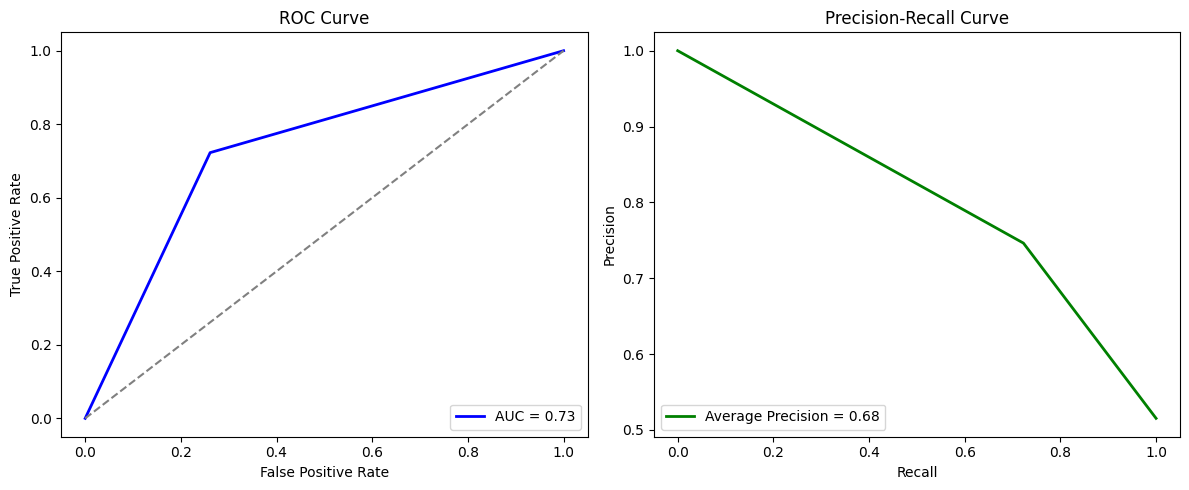

{'F1': 0.7343589743589743, 'Best_Threshold': np.float64(0.01), 'AUC': 0.7307824730279268, 'ROC': {'fpr': array([0.        , 0.26118068, 1.        ]), 'tpr': array([0.        , 0.72274563, 1.        ]), 'thresholds': array([inf,  1.,  0.])}, 'Precision_Recall_Curve': {'precision': array([0.51534593, 0.74635163, 1.        ]), 'recall': array([1.        , 0.72274563, 0.        ]), 'thresholds': array([0, 1])}, 'Average_Precision': 0.6823042924871414}


In [10]:
result = evaluate_nn_model(model, X_test, Y_test)
print(result)

181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 548us/step


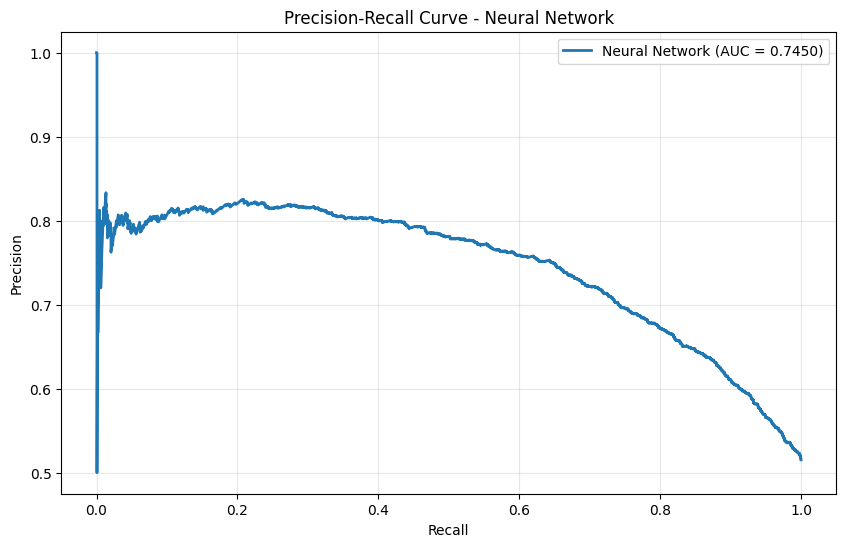

Neural Network PR-AUC: 0.7450


In [ ]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# Get probability predictions for test set
y_pred_proba_nn = model.predict(X_test).flatten()  # flatten() converts (n,1) to (n,)

# Calculate precision-recall curve
precision_nn, recall_nn, thresholds_nn = precision_recall_curve(Y_test, y_pred_proba_nn)
pr_auc_nn = auc(recall_nn, precision_nn)

# Plot precision-recall curve
plt.figure(figsize=(10, 6))
plt.plot(recall_nn, precision_nn, label=f'Neural Network (AUC = {pr_auc_nn:.4f})', linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Neural Network')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Neural Network PR-AUC: {pr_auc_nn:.4f}")

## Getting Raw probability values

In [ ]:
# For any scikit-learn model (LogisticRegression, RandomForest, XGBoost, etc.)
single_patient_data = np.array([[63.0, 26.7, 2, 89.0, 1, 3, 130.0]])

for model_name, model in models.items():
    prob = model.predict_proba(single_patient_data)[0][1]
    print(f"{model_name}: {prob:.4f} ({prob*100:.2f}%)")


LogisticRegression: 0.8536 (85.36%)
Random Forest: 0.9100 (91.00%)
XGBoost: 0.8480 (84.80%)
LightGBM: 0.7781 (77.81%)


d:\ACADEMY FOLDER\IUT Academics\Semester 6 (3.2)\ML\Hybrid-CVD-Model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
d:\ACADEMY FOLDER\IUT Academics\Semester 6 (3.2)\ML\Hybrid-CVD-Model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
d:\ACADEMY FOLDER\IUT Academics\Semester 6 (3.2)\ML\Hybrid-CVD-Model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
